# Djinni NLP Jobs Classifier — Modeling
Comparing TF-IDF + Logistic Regression, Zero-shot BERT, and Fine-tuned DistilBERT.

## 1. Loading Data & Imports

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline, DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
df = pd.read_csv('../data/djinni_processed.csv')

In [3]:
# checking if cuda works
print(torch.cuda.is_available())  # має бути True
print(torch.cuda.get_device_name(0))  # RTX 4090

True
NVIDIA GeForce RTX 4090 Laptop GPU


## 2. TF-IDF + Logistic Regression

In [4]:
y = df['Primary Keyword']
X = df['Clean_description']
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2), max_df=0.8, min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [5]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

In [6]:
print(classification_report(y_test, y_pred_lr))

                   precision    recall  f1-score   support

             .NET       0.87      0.79      0.83       157
          Android       0.89      0.84      0.87        96
           Artist       0.83      0.68      0.74        71
 Business Analyst       0.71      0.80      0.75       201
              C++       0.75      0.67      0.71        81
     Data Analyst       0.55      0.54      0.55        68
    Data Engineer       0.73      0.35      0.48        31
     Data Science       0.80      0.52      0.63        64
           Design       0.85      0.86      0.85       207
           DevOps       0.77      0.84      0.80       172
          Flutter       0.92      0.52      0.67        21
           Golang       1.00      0.33      0.50        33
               HR       0.80      0.85      0.82       186
             Java       0.88      0.82      0.85       145
       JavaScript       0.71      0.90      0.79       462
             Lead       1.00      0.11      0.19       

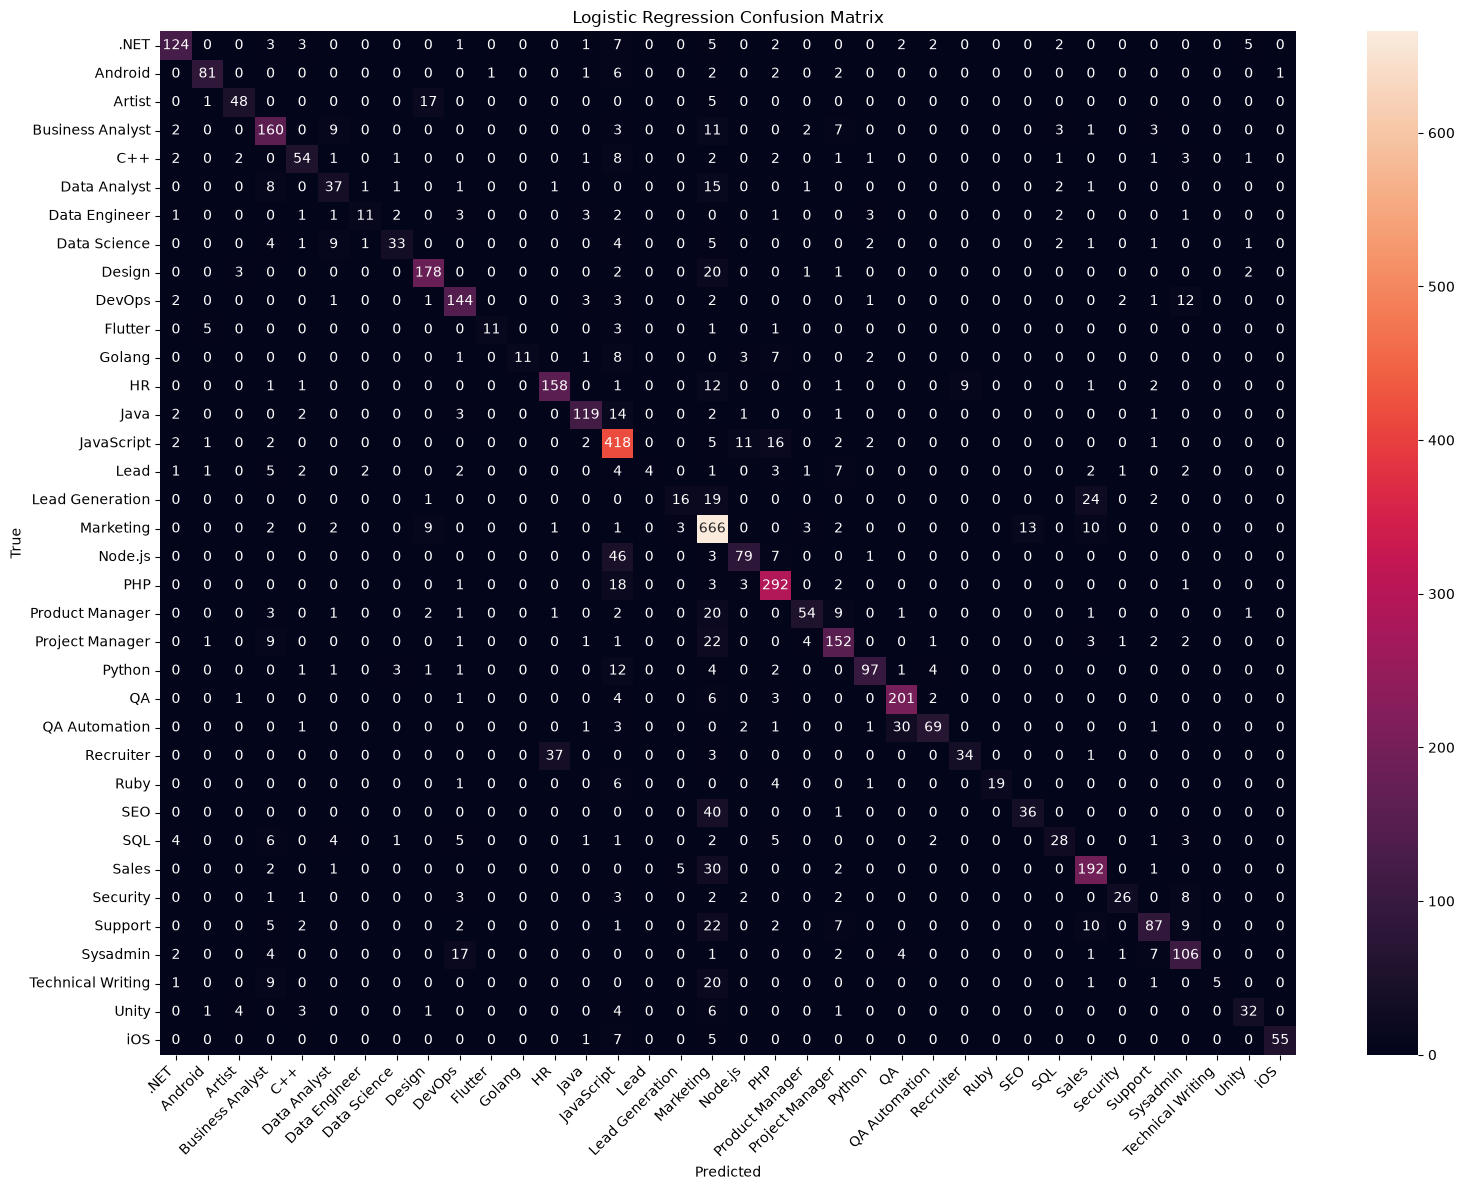

In [7]:
cm = confusion_matrix(y_test, y_pred_lr, labels=model_lr.classes_)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. TF-IDF + LinearSVC

In [8]:
model_svc = LinearSVC()
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)

In [9]:
print(classification_report(y_test, y_pred_svc))

                   precision    recall  f1-score   support

             .NET       0.86      0.83      0.84       157
          Android       0.89      0.86      0.88        96
           Artist       0.71      0.70      0.71        71
 Business Analyst       0.78      0.79      0.78       201
              C++       0.77      0.83      0.80        81
     Data Analyst       0.56      0.72      0.63        68
    Data Engineer       0.75      0.58      0.65        31
     Data Science       0.67      0.58      0.62        64
           Design       0.83      0.87      0.85       207
           DevOps       0.81      0.85      0.83       172
          Flutter       0.78      0.86      0.82        21
           Golang       0.83      0.76      0.79        33
               HR       0.83      0.83      0.83       186
             Java       0.89      0.88      0.89       145
       JavaScript       0.83      0.85      0.84       462
             Lead       0.67      0.32      0.43       

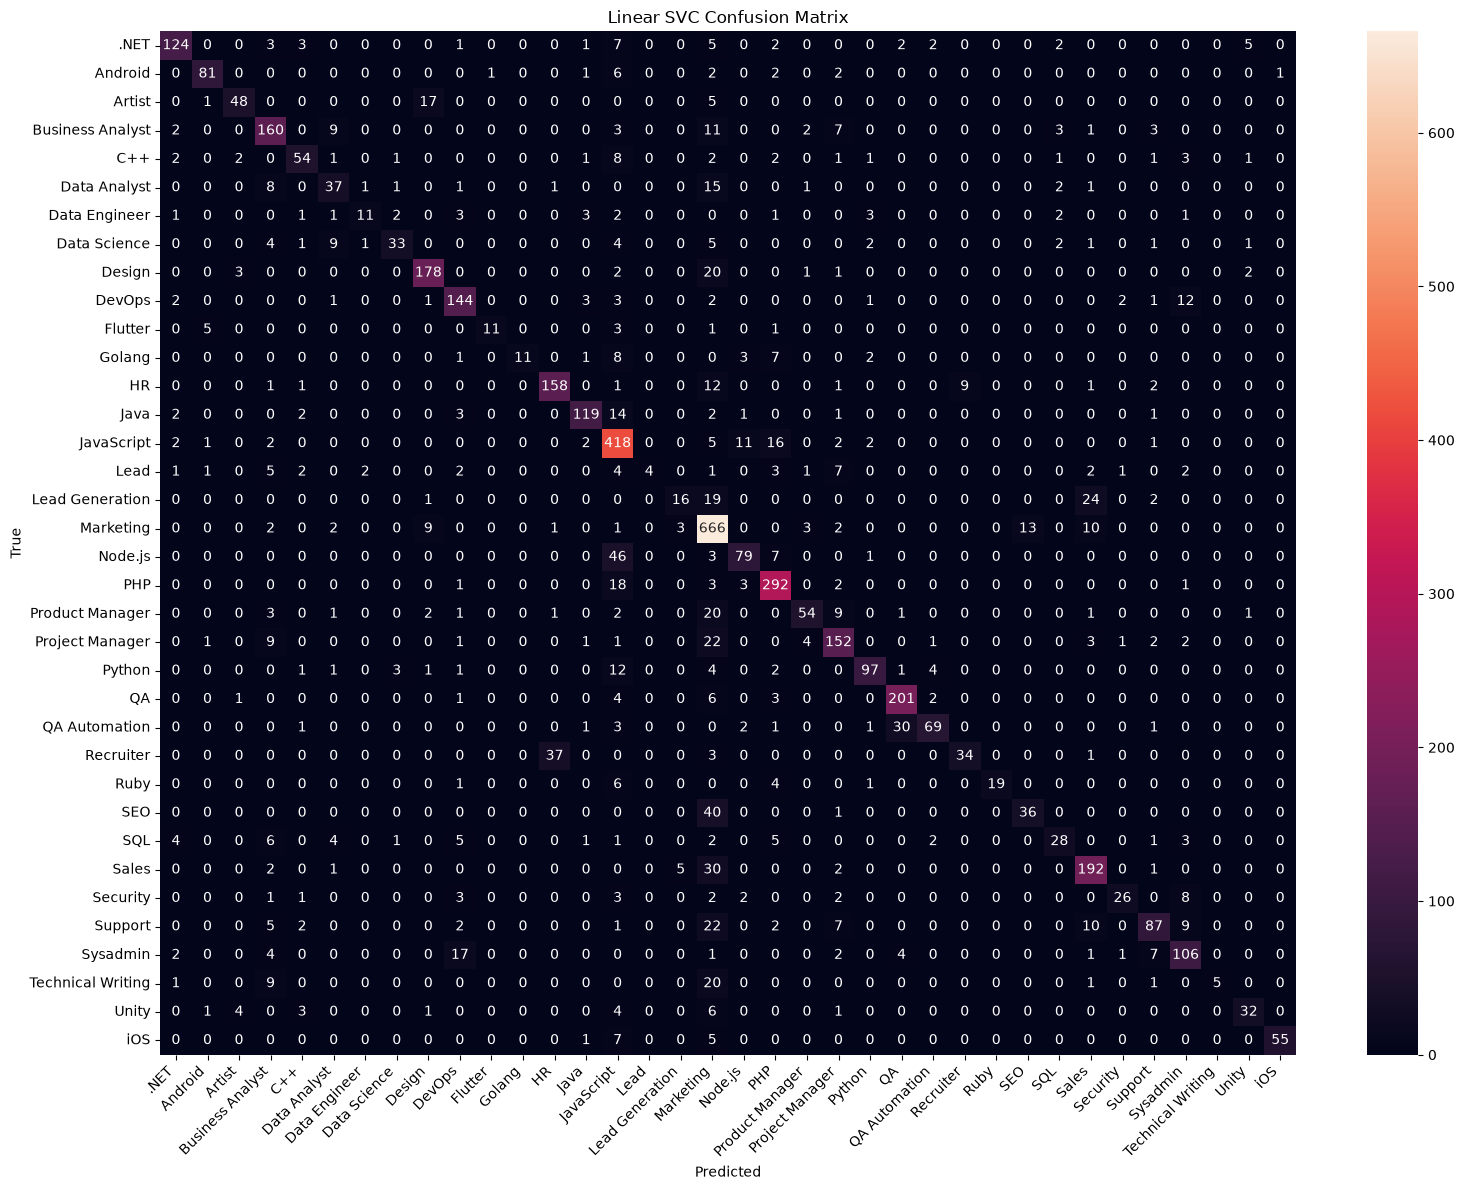

In [10]:
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=model_svc.classes_)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model_svc.classes_, yticklabels=model_svc.classes_)
plt.title('Linear SVC Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Zero-shot mDeBERTa

In [11]:
# we use 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli' because its multilingual
classifier = pipeline(
    'zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
    devoce=0
)

sample_df = df.sample(500, random_state=42)
candidate_labels = list(df['Primary Keyword'].unique())

y_pred_zero = []
for text in sample_df['Clean_description']:
    result = classifier(text[:512], candidate_labels=candidate_labels)
    y_pred_zero.append(result['labels'][0])

print(classification_report(sample_df['Primary Keyword'], y_pred_zero))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                   precision    recall  f1-score   support

             .NET       0.80      0.27      0.40        15
          Android       1.00      0.27      0.43        11
           Artist       0.67      0.80      0.73         5
 Business Analyst       1.00      0.39      0.56        23
              C++       0.00      0.00      0.00         6
     Data Analyst       0.71      0.62      0.67         8
    Data Engineer       0.67      0.50      0.57         4
     Data Science       0.67      0.50      0.57         4
           Design       0.80      0.38      0.52        21
           DevOps       0.38      0.36      0.37        14
          Flutter       1.00      0.50      0.67         2
           Golang       0.50      1.00      0.67         2
               HR       0.50      0.35      0.41        20
             Java       0.73      0.58      0.65        19
       JavaScript       0.70      0.30      0.42        46
             Lead       0.07      0.33      0.11       

C:\Users\ete9n\Documents\coding\pycharm_projects\djinni-nlp-jobs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ete9n\Documents\coding\pycharm_projects\djinni-nlp-jobs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ete9n\Documents\coding\pycharm_projects\djinni-nlp-jobs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

## 5. Fine-tuned DistilBERT

In [12]:
# Primary Keywords are not strings and we need to label encode them into numbers
le = LabelEncoder()
df['label'] = le.fit_transform(df['Primary Keyword'])

In [13]:
train_labels = le.transform(y_train)
test_labels = le.transform(y_test)

In [14]:
tokenizer_bert = DistilBertTokenizer.from_pretrained("distilbert-base-multilingual-cased")

In [15]:
train_encodings = tokenizer_bert(
    list(X_train_text),
    truncation=True,
    padding=True,
    max_length=512
)
test_encodings = tokenizer_bert(
    list(X_test_text),
    truncation=True,
    padding=True,
    max_length=512
)

In [16]:
class JobDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = JobDataset(train_encodings, train_labels)
test_dataset = JobDataset(test_encodings, test_labels)

In [17]:
model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-multilingual-cased',
    num_labels=len(le.classes_)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | Details
------------------------+------------+--------
vocab_projector.bias    | UNEXPECTED |        
vocab_layer_norm.weight | UNEXPECTED |        
vocab_layer_norm.bias   | UNEXPECTED |        
vocab_transform.bias    | UNEXPECTED |        
vocab_transform.weight  | UNEXPECTED |        
classifier.weight       | MISSING    |        
pre_classifier.weight   | MISSING    |        
classifier.bias         | MISSING    |        
pre_classifier.bias     | MISSING    |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
training_args = TrainingArguments(
    output_dir='../models/distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    load_best_model_at_end=True,
)

In [19]:
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.361718,0.959100
2,0.806201,0.749660
3,0.623081,0.718052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3744, training_loss=1.0635649200178618, metrics={'train_runtime': 944.6967, 'train_samples_per_second': 63.363, 'train_steps_per_second': 3.963, 'total_flos': 7934173921677312.0, 'train_loss': 1.0635649200178618, 'epoch': 3.0})

In [20]:
predictions = trainer.predict(test_dataset)
y_pred_bert = predictions.predictions.argmax(axis=1)
y_pred_bert_labels = le.inverse_transform(y_pred_bert)
y_test_labels = le.inverse_transform(test_labels)

print(classification_report(y_test_labels, y_pred_bert_labels))

                   precision    recall  f1-score   support

             .NET       0.88      0.80      0.84       157
          Android       0.91      0.84      0.88        96
           Artist       0.71      0.69      0.70        71
 Business Analyst       0.71      0.79      0.75       201
              C++       0.59      0.79      0.68        81
     Data Analyst       0.56      0.69      0.62        68
    Data Engineer       0.83      0.16      0.27        31
     Data Science       0.60      0.55      0.57        64
           Design       0.80      0.91      0.85       207
           DevOps       0.83      0.81      0.82       172
          Flutter       0.69      0.95      0.80        21
           Golang       0.93      0.85      0.89        33
               HR       0.83      0.81      0.82       186
             Java       0.91      0.88      0.89       145
       JavaScript       0.85      0.84      0.85       462
             Lead       0.73      0.29      0.42       

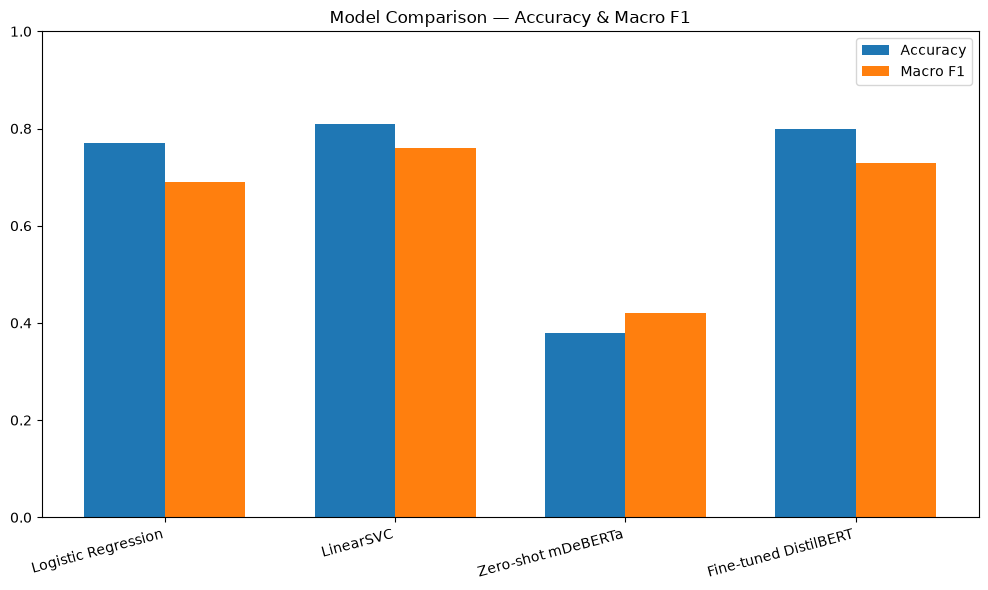

In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LinearSVC', 'Zero-shot mDeBERTa', 'Fine-tuned DistilBERT'],
    'Accuracy': [0.77, 0.81, 0.38, 0.80],
    'Macro F1': [0.69, 0.76, 0.42, 0.73]
})

x = range(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - width/2 for i in x], results['Accuracy'], width, label='Accuracy')
ax.bar([i + width/2 for i in x], results['Macro F1'], width, label='Macro F1')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Accuracy & Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusions

We compared four NLP approaches for multi-class job posting classification across 35 categories.

| Model | Accuracy | Macro F1 | Train Time |
|-------|----------|----------|------------|
| Logistic Regression | 0.77 | 0.69 | seconds |
| LinearSVC | 0.81 | 0.76 | seconds |
| Zero-shot mDeBERTa | 0.38 | 0.42 | ~15 min |
| Fine-tuned DistilBERT | 0.80 | 0.73 | ~24 min |

**Key insights:**
- LinearSVC outperforms fine-tuned DistilBERT on this dataset — a strong reminder that classical ML is not dead
- Zero-shot BERT without training data performs poorly on domain-specific Ukrainian job postings
- Fine-tuning BERT requires significant compute but gives competitive results
- Hardest categories: `Lead`, `Technical Writing`, `Data Engineer` — too few examples and overlapping descriptions
- TF-IDF + LinearSVC is the best price/quality tradeoff for production: fast, interpretable, accurate

In [25]:
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(model_svc, '../models/linear_svc.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

['../models/label_encoder.pkl']